## Part 1: EDA & Preprocessing

### Explore Distributions

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../Data/facebook+metrics/dataset_Facebook.csv", sep=";")
data.shape



(500, 19)

In [6]:
data.dtypes

Page total likes                                                         int64
Type                                                                       str
Category                                                                 int64
Post Month                                                               int64
Post Weekday                                                             int64
Post Hour                                                                int64
Paid                                                                   float64
Lifetime Post Total Reach                                                int64
Lifetime Post Total Impressions                                          int64
Lifetime Engaged Users                                                   int64
Lifetime Post Consumers                                                  int64
Lifetime Post Consumptions                                               int64
Lifetime Post Impressions by people who have liked y

In [7]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    str    
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime Post Total

In [8]:
data.head()

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393


In [9]:
data.describe()

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
count,500.000000,500.000000,500.000000,500.000000,500.000000,499.000000,500.00000,5.000000e+02,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.00000,499.000000,496.000000,500.000000
mean,123194.176000,1.880000,7.038000,4.150000,7.840000,0.278557,13903.36000,2.958595e+04,920.344000,798.772000,1415.130000,1.676638e+04,6585.488000,609.986000,7.48200,177.945892,27.266129,212.120000
std,16272.813214,0.852675,3.307936,2.030701,4.368589,0.448739,22740.78789,7.680325e+04,985.016636,882.505013,2000.594118,5.979102e+04,7682.009405,612.725618,21.18091,323.398742,42.613292,380.233118
min,81370.000000,1.000000,1.000000,1.000000,1.000000,0.000000,238.00000,5.700000e+02,9.000000,9.000000,9.000000,5.670000e+02,236.000000,9.000000,0.00000,0.000000,0.000000,0.000000
25%,112676.000000,1.000000,4.000000,2.000000,3.000000,0.000000,3315.00000,5.694750e+03,393.750000,332.500000,509.250000,3.969750e+03,2181.500000,291.000000,1.00000,56.500000,10.000000,71.000000
50%,129600.000000,2.000000,7.000000,4.000000,9.000000,0.000000,5281.00000,9.051000e+03,625.500000,551.500000,851.000000,6.255500e+03,3417.000000,412.000000,3.00000,101.000000,19.000000,123.500000
75%,136393.000000,3.000000,10.000000,6.000000,11.000000,1.000000,13168.00000,2.208550e+04,1062.000000,955.500000,1463.000000,1.486050e+04,7989.000000,656.250000,7.00000,187.500000,32.250000,228.500000
max,139441.000000,3.000000,12.000000,7.000000,23.000000,1.000000,180480.00000,1.110282e+06,11452.000000,11328.000000,19779.000000,1.107833e+06,51456.000000,4376.000000,372.00000,5172.000000,790.000000,6334.000000


### Distributions: Histograms

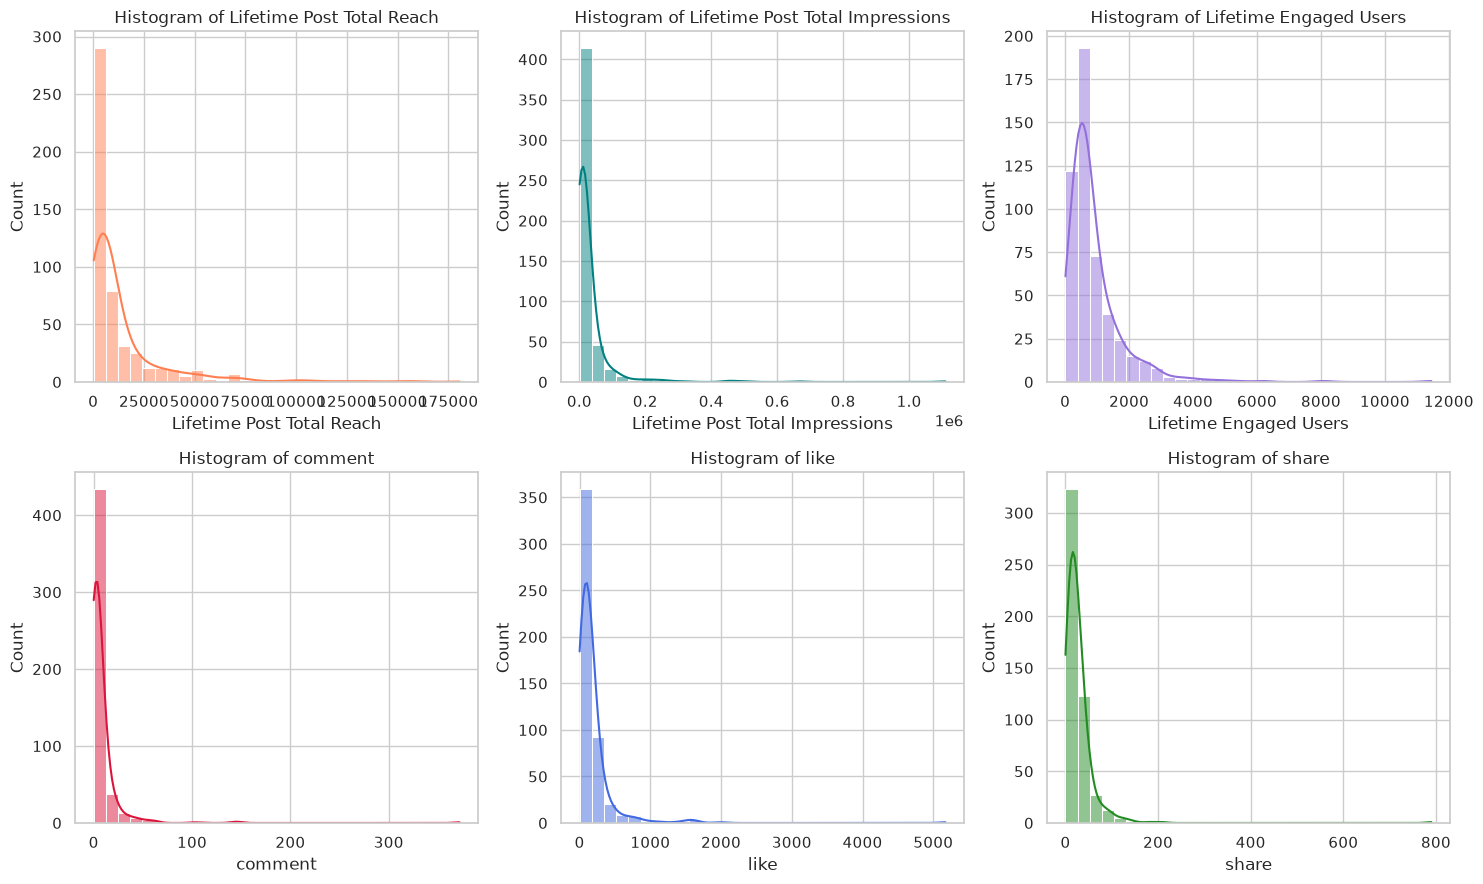

In [10]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

histogram_vars = [
    ('Lifetime Post Total Reach', 'coral'),
    ('Lifetime Post Total Impressions', 'teal'),
    ('Lifetime Engaged Users', 'mediumpurple'),
    ('comment', 'crimson'),
    ('like', 'royalblue'),
    ('share', 'forestgreen')
]

for i, (col, color) in enumerate(histogram_vars):
    sns.histplot(data[col].dropna(), bins=30, kde=True, ax=axes[i], color=color)
    axes[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

Lifetime Post Total Reach:  a long‑tail shape, meaning the data is very uneven and has outliers. Most posts don’t reach many people, and only a few reach a very large audience. 

Lifetime Post Total Impressions: Impressions show the same pattern. There are lots of posts with low numbers and a small number with very high impressions.

Lifetime Engaged Users: Most posts have low engagement, while a few posts have very high engagement.

Comments: Comment counts are mostly low, with only a few posts getting a lot of comments. This sparse pattern shows the data has many small values and a few big ones.

Likes: Most posts get a modest number of likes, and a few get a ton. 

Shares: Are mostly zero or very low, with only a handful of posts being shared a lot.

### Relationships: Correlation Matrix

In [ ]:

correlation_columns = [
    'Page total likes', 'Lifetime Post Total Reach', 'Lifetime Post Total Impressions',
    'Lifetime Engaged Users', 'Lifetime Post Consumers', 'Lifetime Post Consumptions',
    'comment', 'like', 'share', 'Total Interactions'
]

corr_matrix = data[correlation_columns].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Matrix of Facebook Post Metrics", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.close()

#Saved figure that has a separate png file in our project

<function matplotlib.pyplot.show(close=None, block=None)>

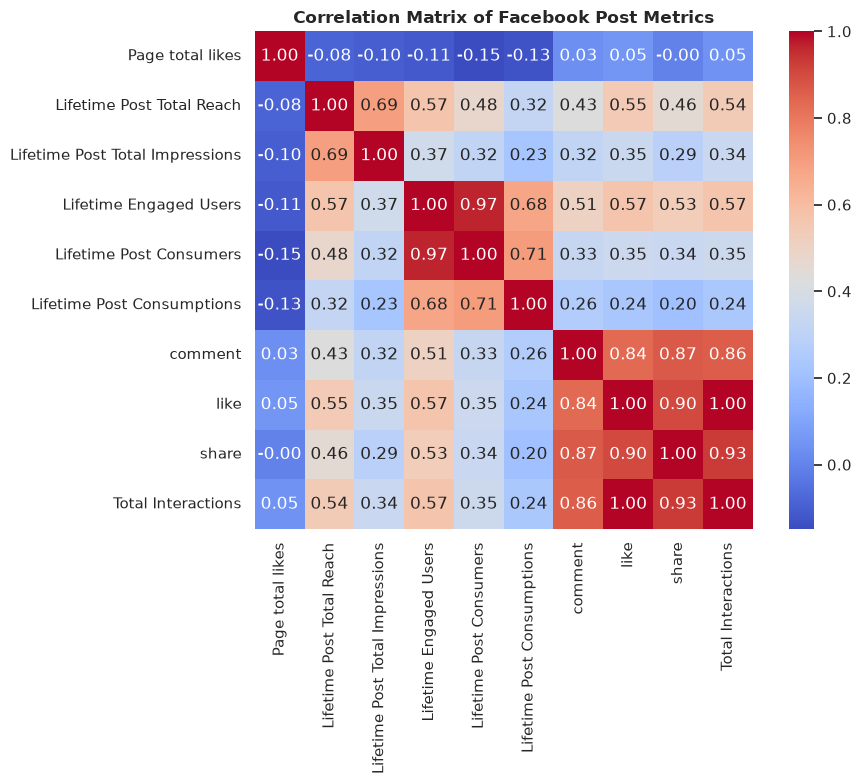

In [ ]:

correlation_columns = [
    'Page total likes', 'Lifetime Post Total Reach', 'Lifetime Post Total Impressions',
    'Lifetime Engaged Users', 'Lifetime Post Consumers', 'Lifetime Post Consumptions',
    'comment', 'like', 'share', 'Total Interactions'
]

corr_matrix = data[correlation_columns].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Matrix of Facebook Post Metrics", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show

#Many of the engagement metrics move together — when one goes up, the others usually go up too. This means some features might be repeating the same information. In preprocessing, we’ll check for these overlaps and decide which features to keep.


### Data Quality Issues

In [12]:

missing_counts = data.isnull().sum()
print(missing_counts)
print("\n")
duplicate_counts = data.duplicated().sum()
print("Total Duplicate Rows: ", duplicate_counts)


Page total likes                                                       0
Type                                                                   0
Category                                                               0
Post Month                                                             0
Post Weekday                                                           0
Post Hour                                                              0
Paid                                                                   1
Lifetime Post Total Reach                                              0
Lifetime Post Total Impressions                                        0
Lifetime Engaged Users                                                 0
Lifetime Post Consumers                                                0
Lifetime Post Consumptions                                             0
Lifetime Post Impressions by people who have liked your Page           0
Lifetime Post reach by people who like your Page   